# Análisis Exploratorio de Datos (EDA) - Superstore Sales

## 1. Documentación del Dataset

- **Nombre del Dataset:** Superstore Sales Data
- **Fuente:** Datos de ventas de una supertienda (comúnmente utilizado para análisis de negocio).
- **Contexto del Problema:** Este dataset contiene información detallada sobre las ventas de una supertienda, incluyendo datos de clientes, productos, pedidos y ganancias. El objetivo principal es realizar un análisis exploratorio para entender los patrones de ventas, identificar factores que influyen en la rentabilidad y descubrir oportunidades de mejora.
- **Dimensiones:** Se determinarán al cargar el dataset, pero se espera que contenga varias columnas relacionadas con pedidos, productos, clientes y métricas financieras.
- **Tipo de Problema:** Análisis de Negocio, Estadística Descriptiva, Identificación de Patrones, Preparación para Modelado Predictivo (si se busca predecir ganancias o ventas).
- **Variable Objetivo:** `Profit` (Ganancia).
- **Integrantes del Equipo:**
    - Camilo Velasquez Restrepo
    - Mateo
    - Daniela

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Cargar el dataset
try:
    df = pd.read_csv('sample_-_superstore.csv', encoding='latin1') # Intentar con latin1 si utf-8 falla
except UnicodeDecodeError:
    df = pd.read_csv('sample_-_superstore.csv', encoding='utf-8')

print("Dataset cargado exitosamente.")

Dataset cargado exitosamente.


## 2. Inspección Inicial del Dataset

En esta sección, realizaremos una primera inspección para comprender la estructura básica del dataset, los tipos de datos y algunas estadísticas descriptivas.

In [3]:
print("\n--- Primeras 5 filas del dataset ---")
display(df.head())

print("\n--- Información general del dataset ---")
df.info()

print("\n--- Estadísticas descriptivas de variables numéricas ---")
display(df.describe())

print("\n--- Forma del dataset (filas, columnas) ---")
print(df.shape)


--- Primeras 5 filas del dataset ---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840



--- Información general del dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  S

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000



--- Forma del dataset (filas, columnas) ---
(10194, 21)


## 3. Análisis de Valores Faltantes

Identificaremos la presencia de valores nulos en cada columna y decidiremos una estrategia de tratamiento justificada.


--- Conteo de valores faltantes por columna ---
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


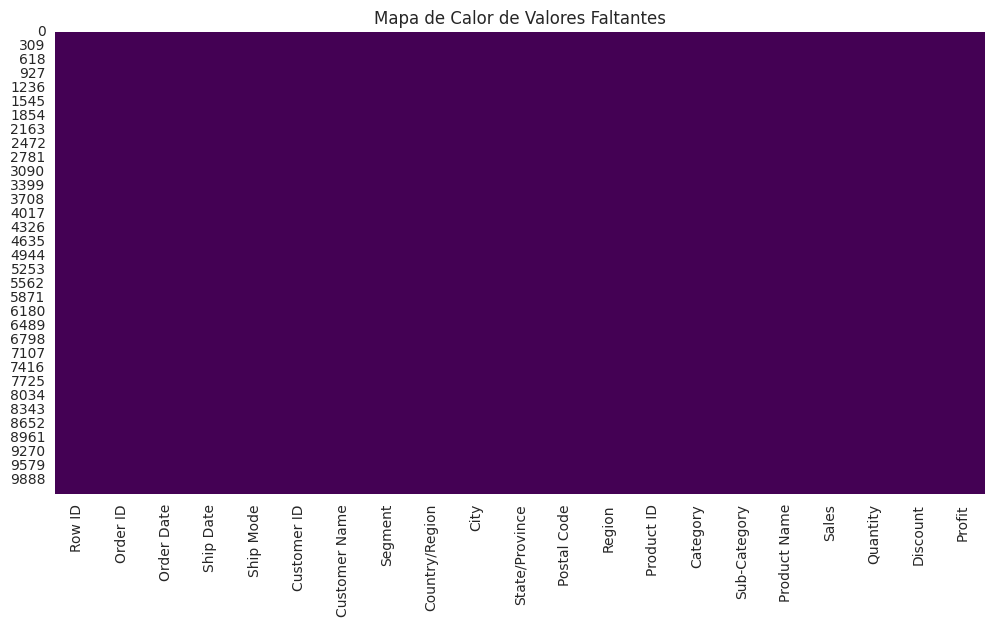

In [4]:
print("\n--- Conteo de valores faltantes por columna ---")
missing_values = df.isnull().sum()
print(missing_values)

# Visualización de valores faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Faltantes')
plt.show()

In [5]:
# Convertir 'Order Date' y 'Ship Date' a formato de fecha
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
print("\n'Order Date' y 'Ship Date' convertidas a formato de fecha.")


'Order Date' y 'Ship Date' convertidas a formato de fecha.


## 4. Distribución de la Variable Objetivo: `Profit`

Analizaremos la distribución de la variable `Profit` para entender su comportamiento, identificar posibles sesgos y la presencia de valores atípicos.


--- Estadísticas descriptivas de la variable objetivo 'Profit' ---


count    10194.000000
mean        28.673417
std        232.465115
min      -6599.978000
25%          1.760800
50%          8.690000
75%         29.297925
max       8399.976000
Name: Profit, dtype: float64

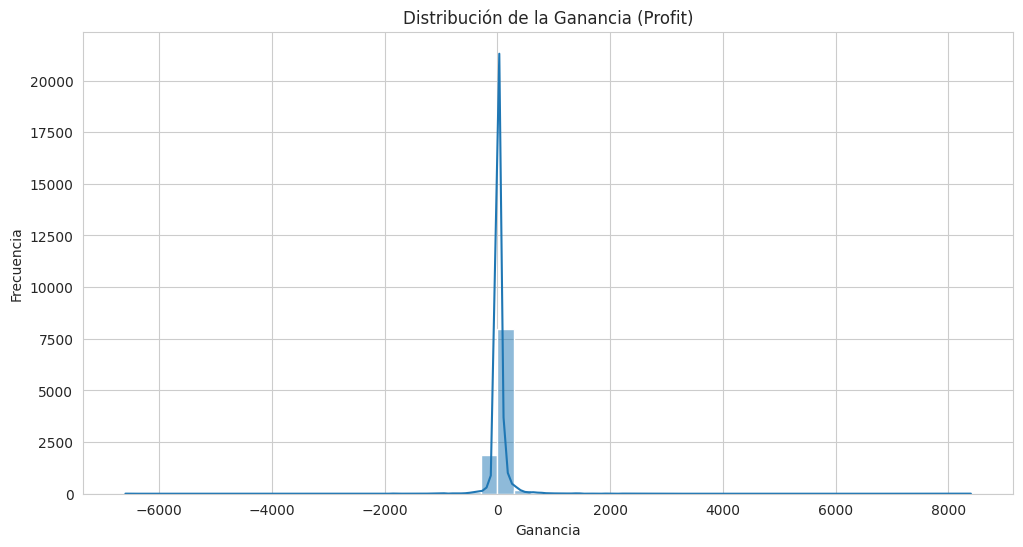

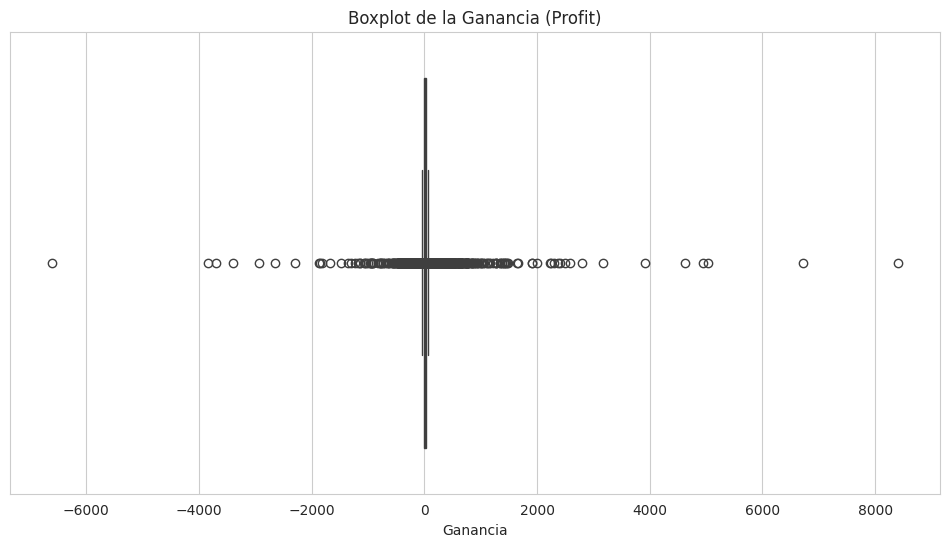

Sesgo de 'Profit': 7.60
Curtosis de 'Profit': 401.69
Número de transacciones con pérdida o sin ganancia: 1966 (19.29%)


In [6]:
print("\n--- Estadísticas descriptivas de la variable objetivo 'Profit' ---")
display(df['Profit'].describe())

plt.figure(figsize=(12, 6))
sns.histplot(df['Profit'], bins=50, kde=True)
plt.title('Distribución de la Ganancia (Profit)')
plt.xlabel('Ganancia')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Profit'])
plt.title('Boxplot de la Ganancia (Profit)')
plt.xlabel('Ganancia')
plt.show()

print(f"Sesgo de 'Profit': {df['Profit'].skew():.2f}")
print(f"Curtosis de 'Profit': {df['Profit'].kurt():.2f}")

# Conteo de valores de Profit <= 0 (pérdidas o sin ganancia)
loss_count = df[df['Profit'] <= 0].shape[0]
total_count = df.shape[0]
print(f"Número de transacciones con pérdida o sin ganancia: {loss_count} ({loss_count/total_count:.2%})")

## 5. Análisis Univariado de Variables Numéricas y Categóricas

Exploraremos la distribución de las variables individuales, identificando patrones, rangos y la presencia de outliers.


--- Análisis Univariado de Variables Numéricas ---

Variable: Sales


count    10194.000000
mean       228.225854
std        619.906839
min          0.444000
25%         17.220000
50%         53.910000
75%        209.500000
max      22638.480000
Name: Sales, dtype: float64

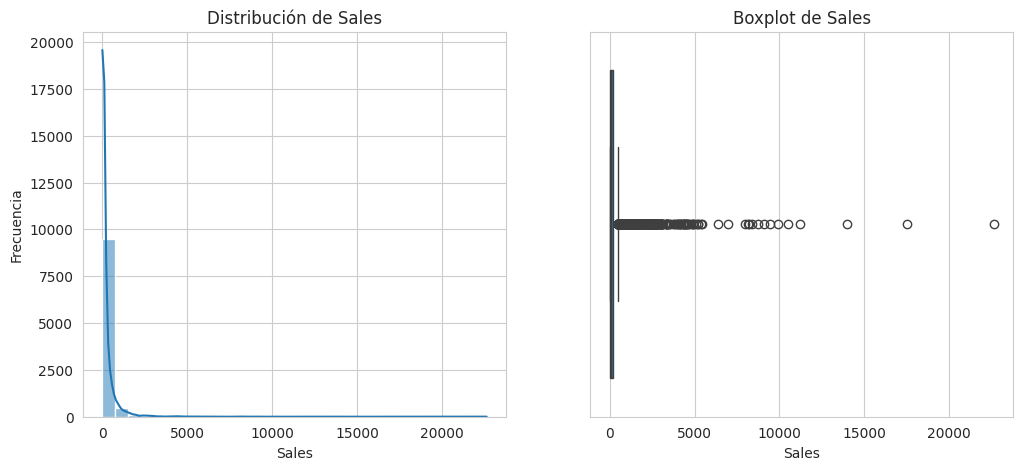

Sesgo de 'Sales': 12.98
Curtosis de 'Sales': 306.37

Variable: Quantity


count    10194.000000
mean         3.791838
std          2.228317
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         14.000000
Name: Quantity, dtype: float64

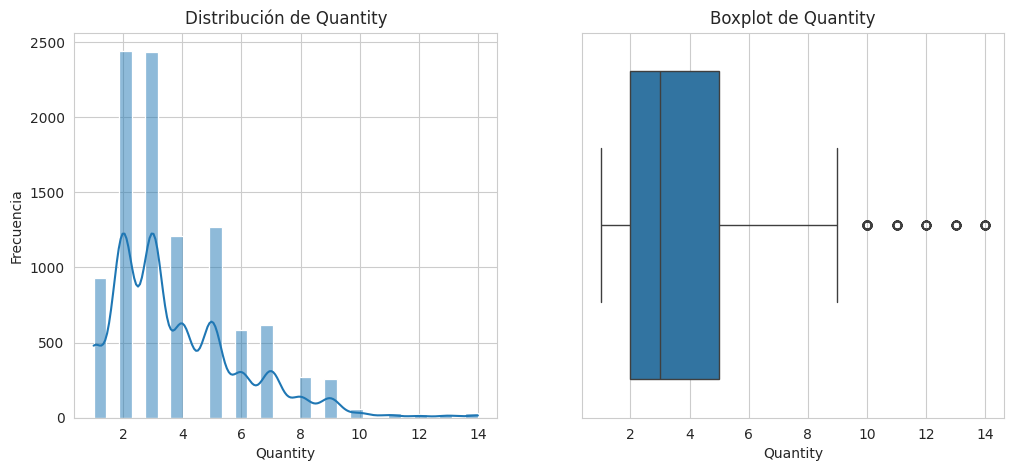

Sesgo de 'Quantity': 1.27
Curtosis de 'Quantity': 1.96

Variable: Discount


count    10194.000000
mean         0.155385
std          0.206249
min          0.000000
25%          0.000000
50%          0.200000
75%          0.200000
max          0.800000
Name: Discount, dtype: float64

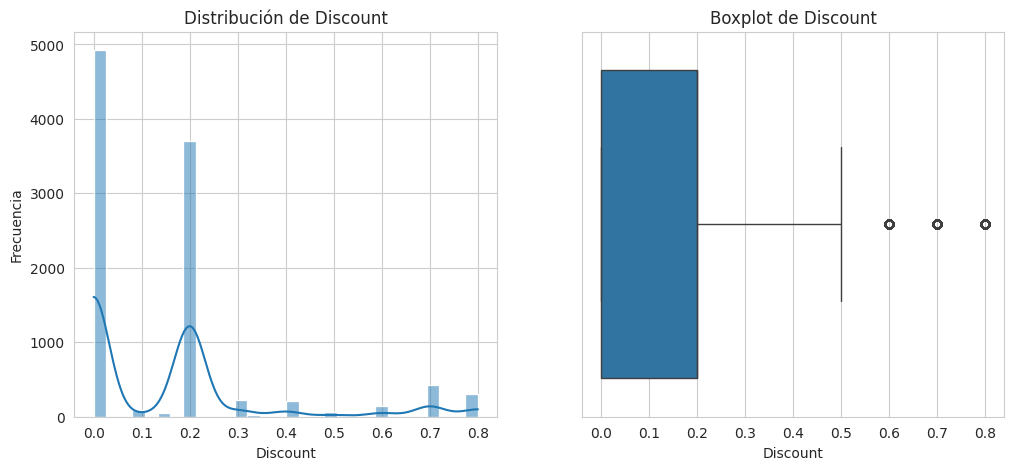

Sesgo de 'Discount': 1.69
Curtosis de 'Discount': 2.42


In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Profit') # Ya analizamos Profit
if 'Row ID' in numerical_cols: numerical_cols.remove('Row ID') # Eliminar ID 
if 'Postal Code' in numerical_cols: numerical_cols.remove('Postal Code') # Eliminar Postal Code ya que sería redundante con la variable de ciudad

print("\n--- Análisis Univariado de Variables Numéricas ---")
for col in numerical_cols:
    print(f"\nVariable: {col}")
    display(df[col].describe())
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()
    print(f"Sesgo de '{col}': {df[col].skew():.2f}")
    print(f"Curtosis de '{col}': {df[col].kurt():.2f}")


--- Análisis Univariado de Variables Categóricas ---
Variables categóricas identificadas: ['Ship Mode', 'Segment', 'Country/Region', 'City', 'State/Province', 'Region', 'Category', 'Sub-Category']

Variable: Ship Mode


Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

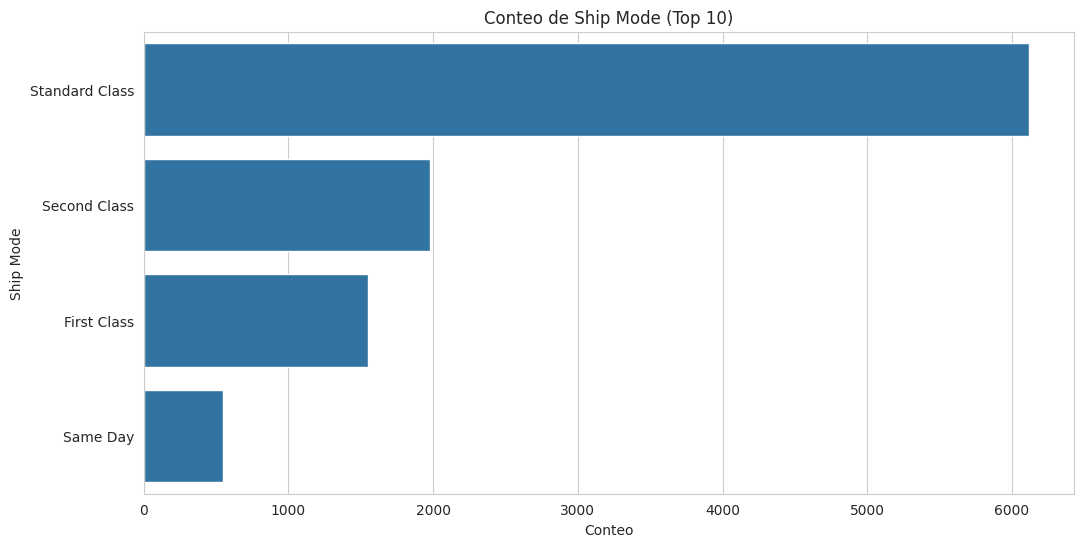


Variable: Segment


Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

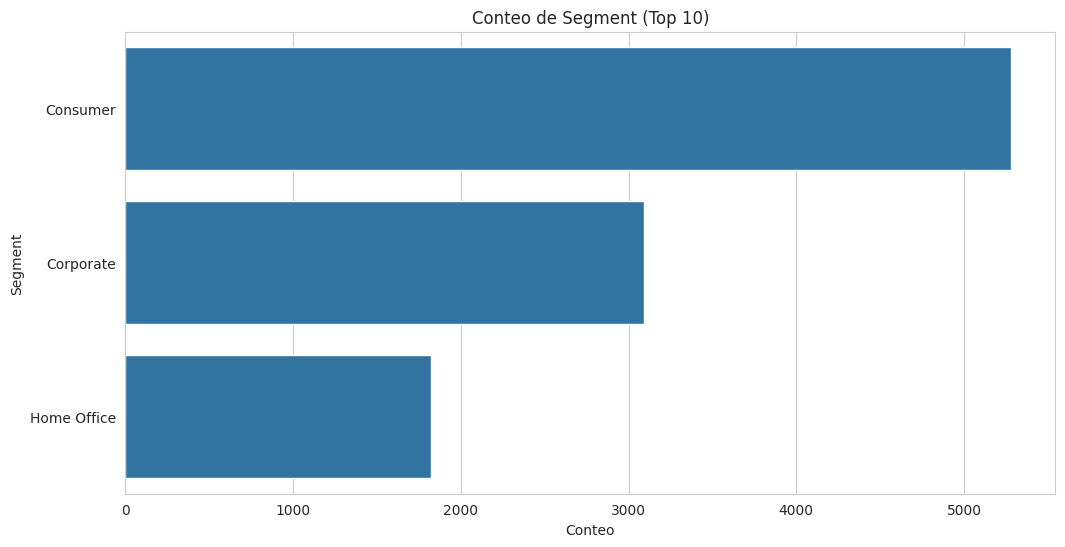


Variable: Country/Region


Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

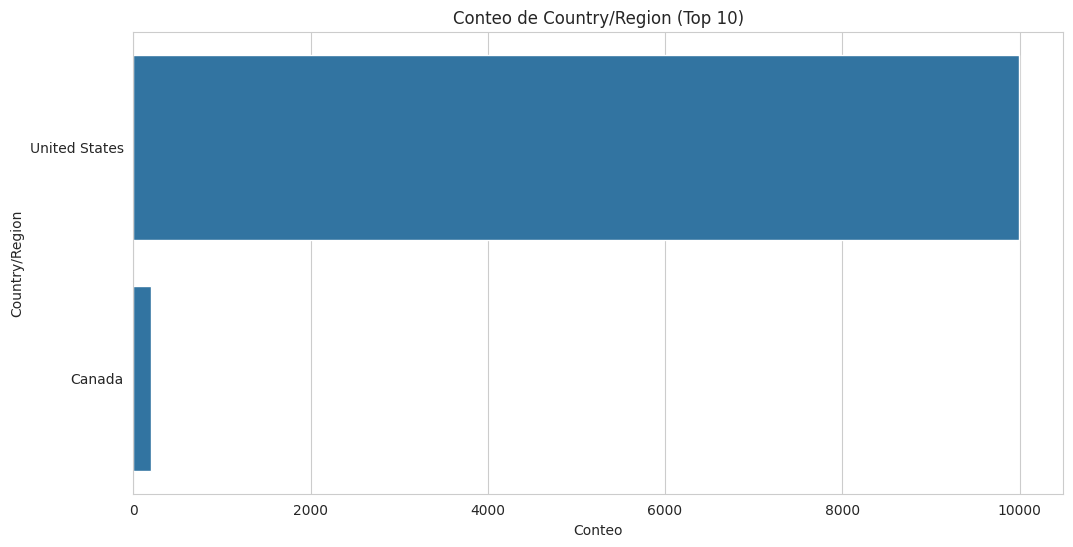


Variable: City


City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Seattle          428
Houston          377
Chicago          314
Columbus         222
San Diego        170
Springfield      163
Name: count, dtype: int64

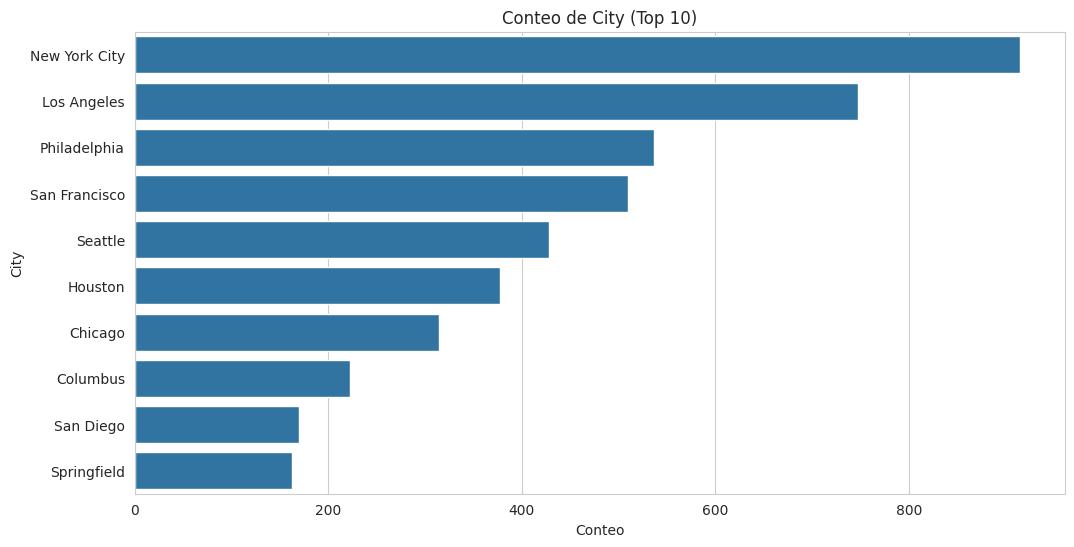


Variable: State/Province


State/Province
California        2001
New York          1128
Texas              985
Pennsylvania       587
Washington         506
Illinois           492
Ohio               469
Florida            383
Michigan           255
North Carolina     249
Name: count, dtype: int64

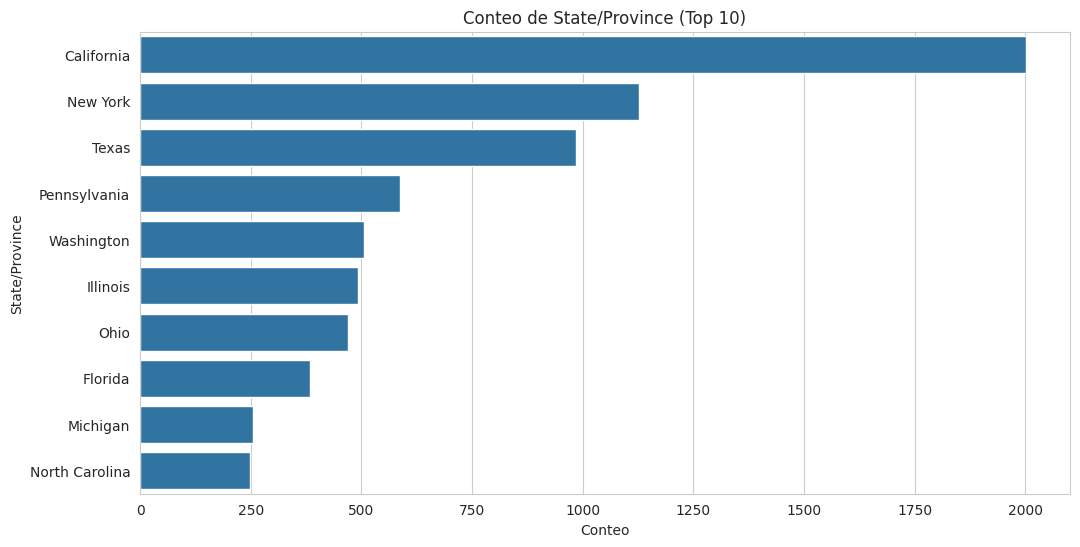


Variable: Region


Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64

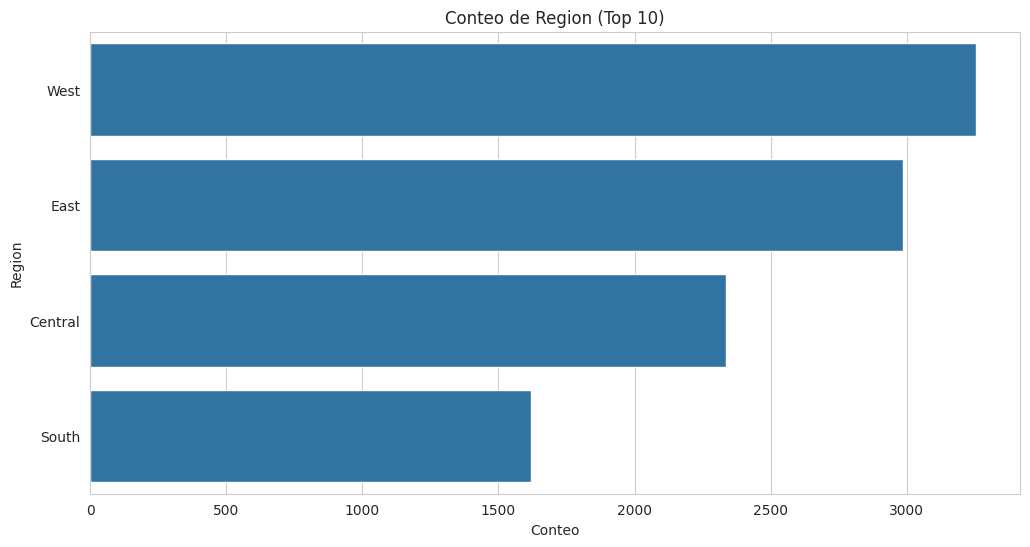


Variable: Category


Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

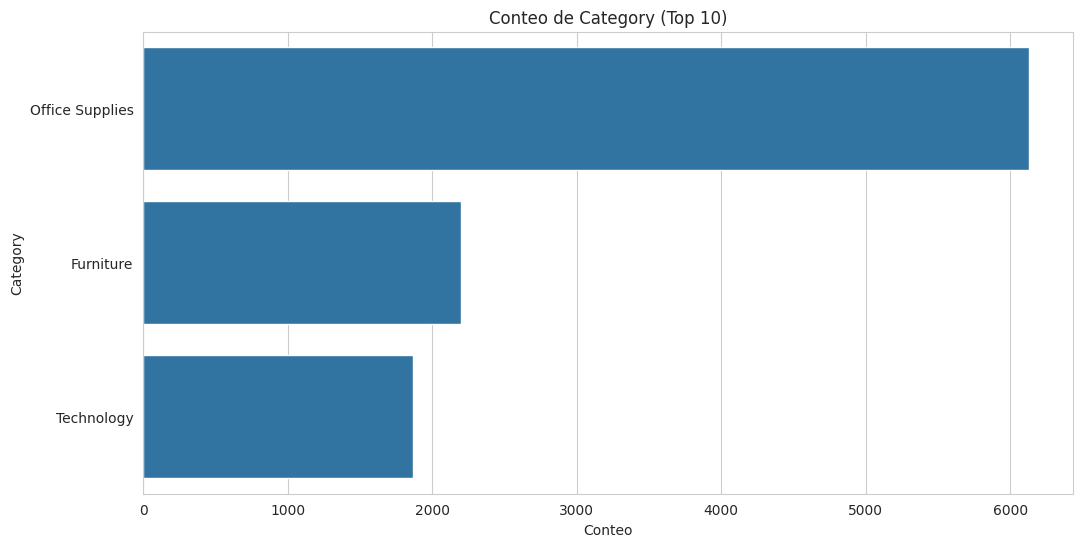


Variable: Sub-Category


Sub-Category
Binders        1548
Paper          1384
Furnishings    1009
Phones          903
Storage         856
Art             821
Accessories     775
Chairs          634
Appliances      474
Labels          368
Name: count, dtype: int64

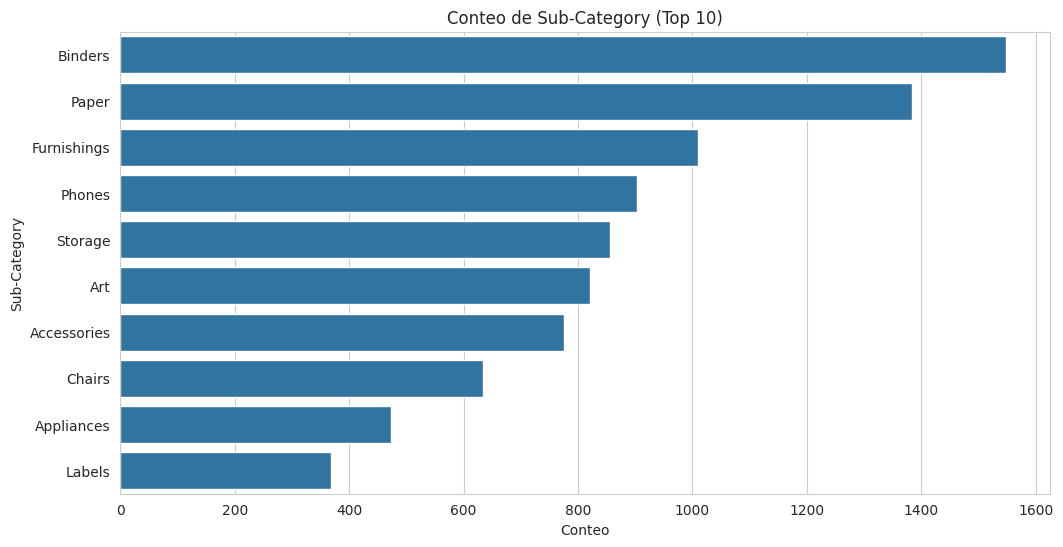

In [8]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
if 'Order ID' in categorical_cols: categorical_cols.remove('Order ID') # Eliminar ID si existe
if 'Customer ID' in categorical_cols: categorical_cols.remove('Customer ID') # Eliminar ID si existe
if 'Product ID' in categorical_cols: categorical_cols.remove('Product ID') # Eliminar ID si existe
if 'Customer Name' in categorical_cols: categorical_cols.remove('Customer Name') # Eliminar nombre si existe
if 'Product Name' in categorical_cols: categorical_cols.remove('Product Name') # Eliminar nombre si existe
if 'Postal Code' in categorical_cols: categorical_cols.remove('Postal Code') # Eliminar Postal Code ya que sería redundante con la variable de ciudad

print("\n--- Análisis Univariado de Variables Categóricas ---")
print(f"Variables categóricas identificadas: {categorical_cols}")

for col in categorical_cols:
    print(f"\nVariable: {col}")
    
    # 1. Obtener el conteo de las 10 categorías más frecuentes
    top_10 = df[col].value_counts().head(10)
    display(top_10)
    
    plt.figure(figsize=(12, 6))
    
    # 2. Filtrar el DataFrame para graficar solo el Top 10
    df_filtered = df[df[col].isin(top_10.index)]
    sns.countplot(y=df_filtered[col], order=top_10.index)
    
    plt.title(f'Conteo de {col} (Top 10)')
    plt.xlabel('Conteo')
    plt.ylabel(col)
    plt.show()

## 6. Análisis Bivariado: Relación entre Features y Target (`Profit`)

Investigaremos cómo las diferentes variables se relacionan con la ganancia (`Profit`).


--- Correlación entre variables numéricas y 'Profit' ---


Profit      1.000000
Sales       0.481460
Quantity    0.066145
Discount   -0.218882
Name: Profit, dtype: float64

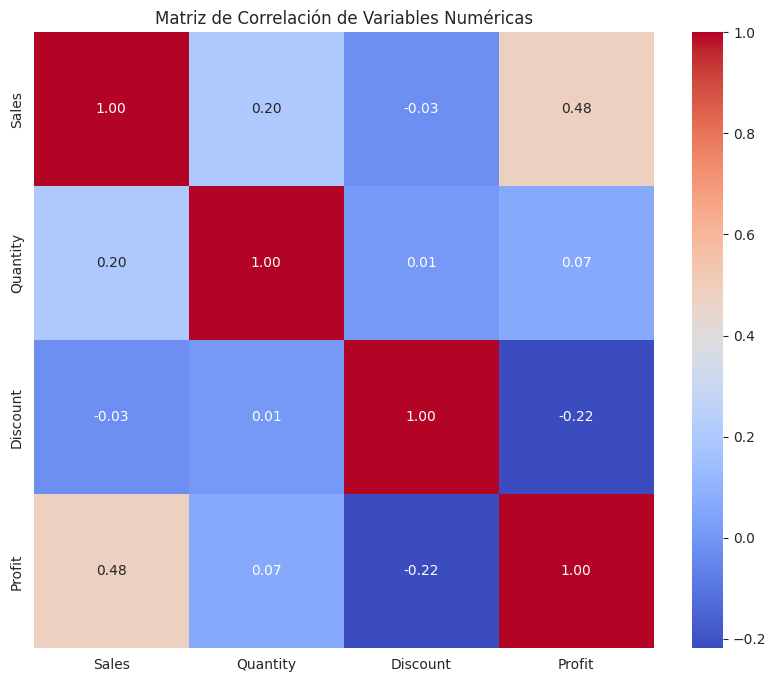


--- Scatterplots de variables numéricas vs. 'Profit' ---


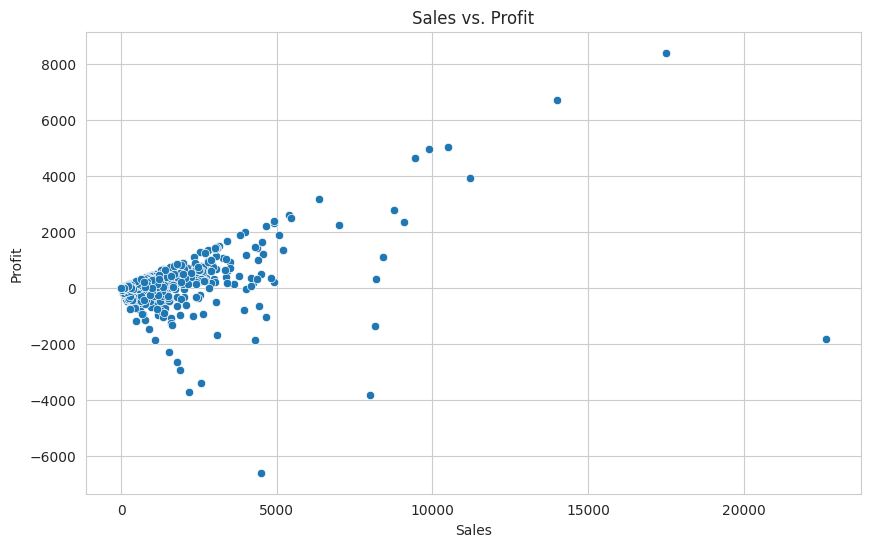

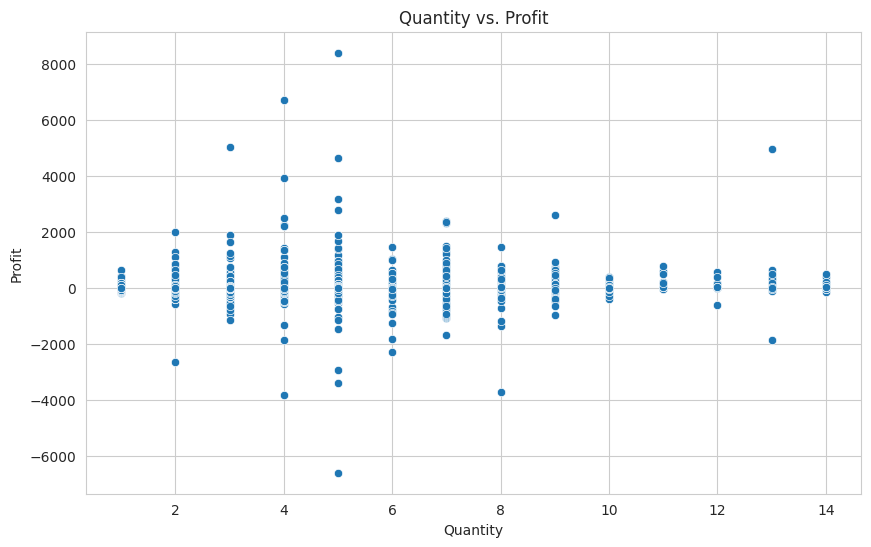

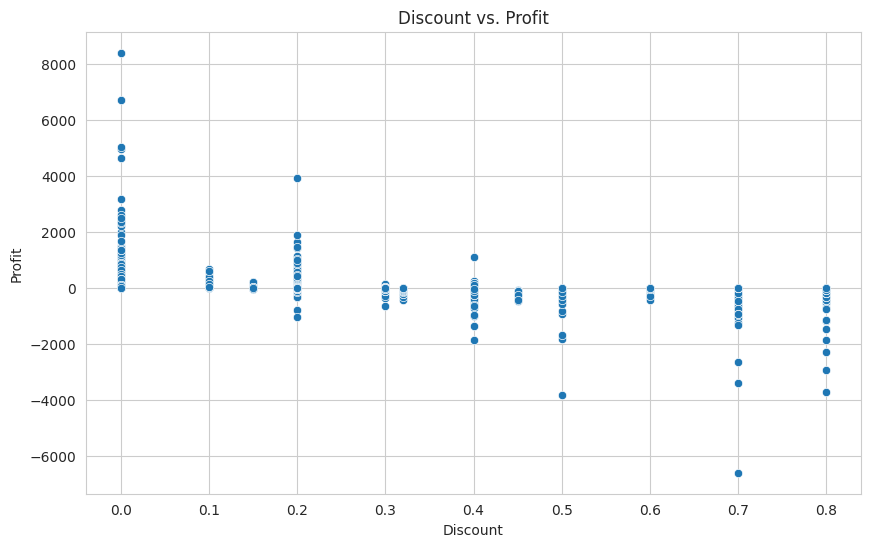


--- Boxplots de variables categóricas vs. 'Profit' ---


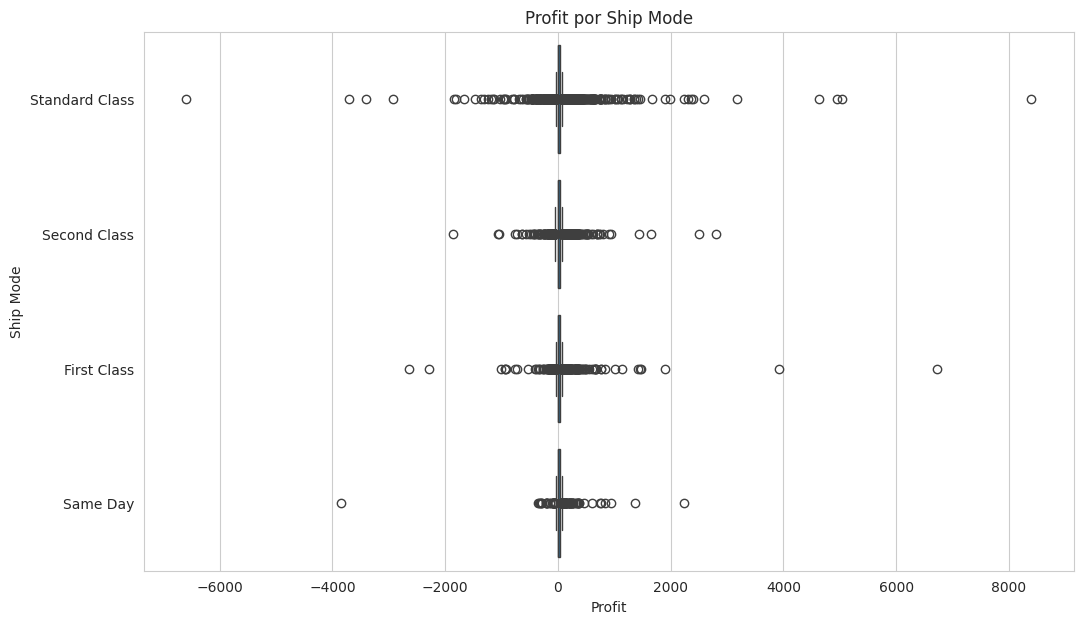

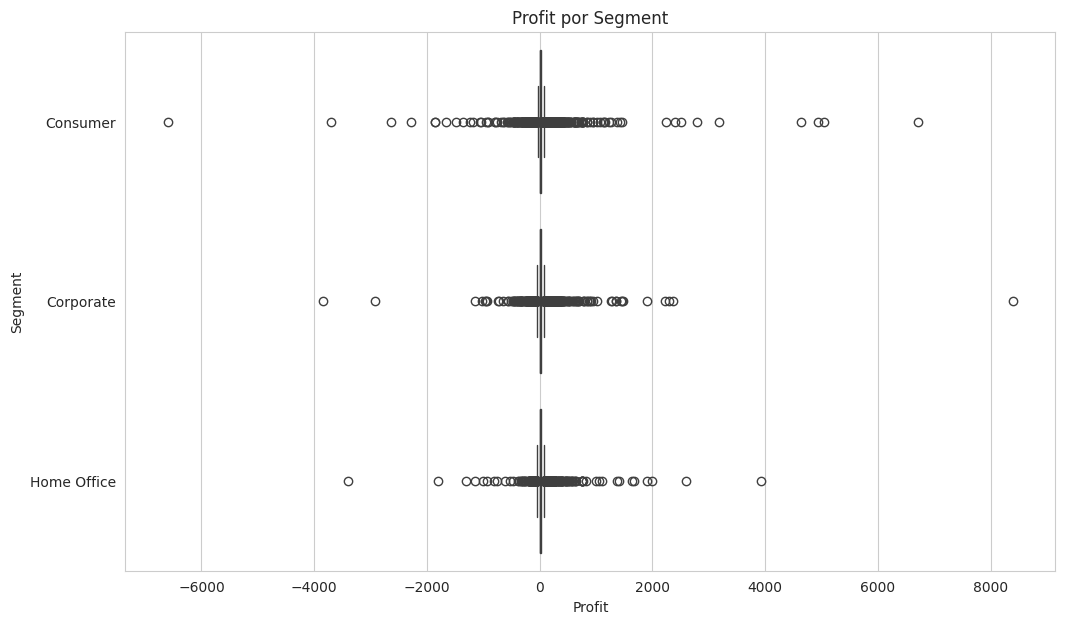

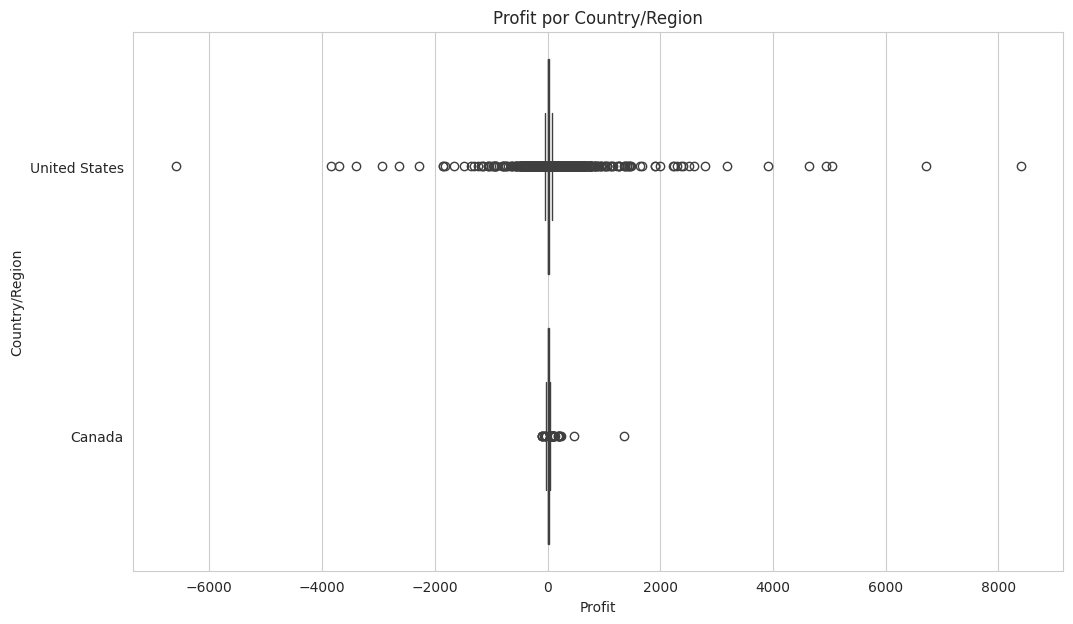

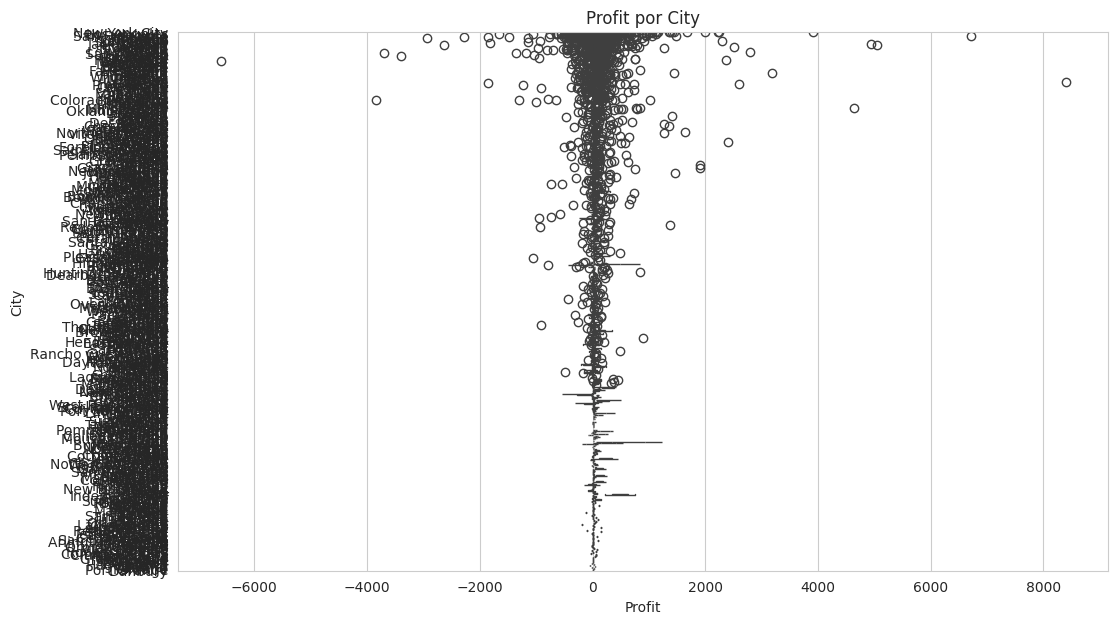

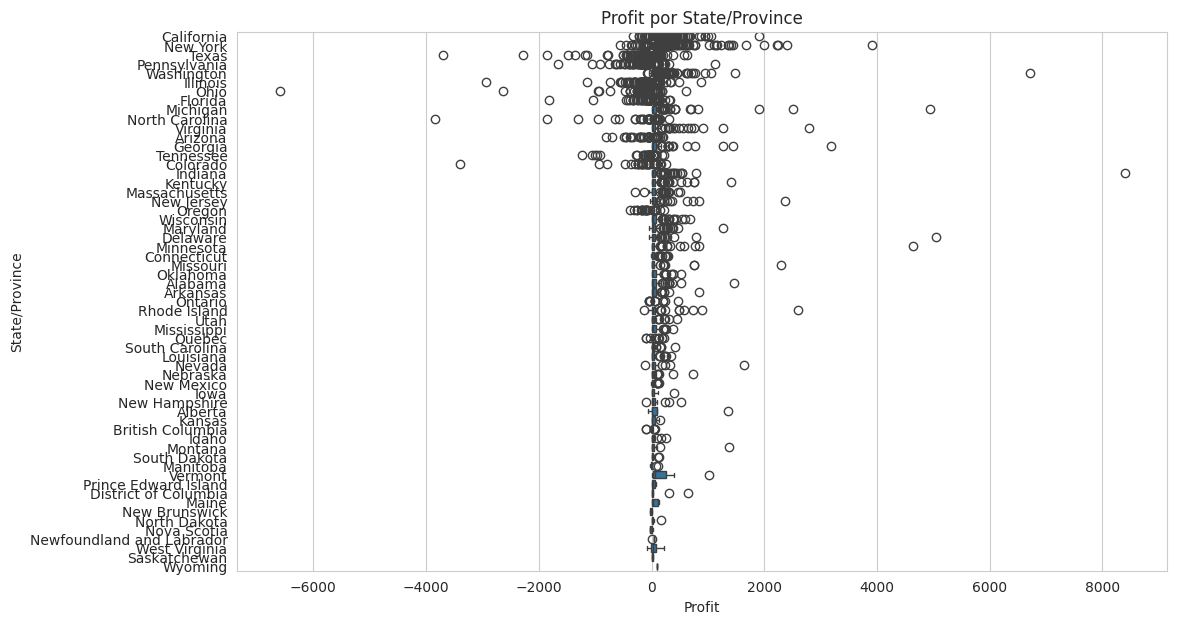

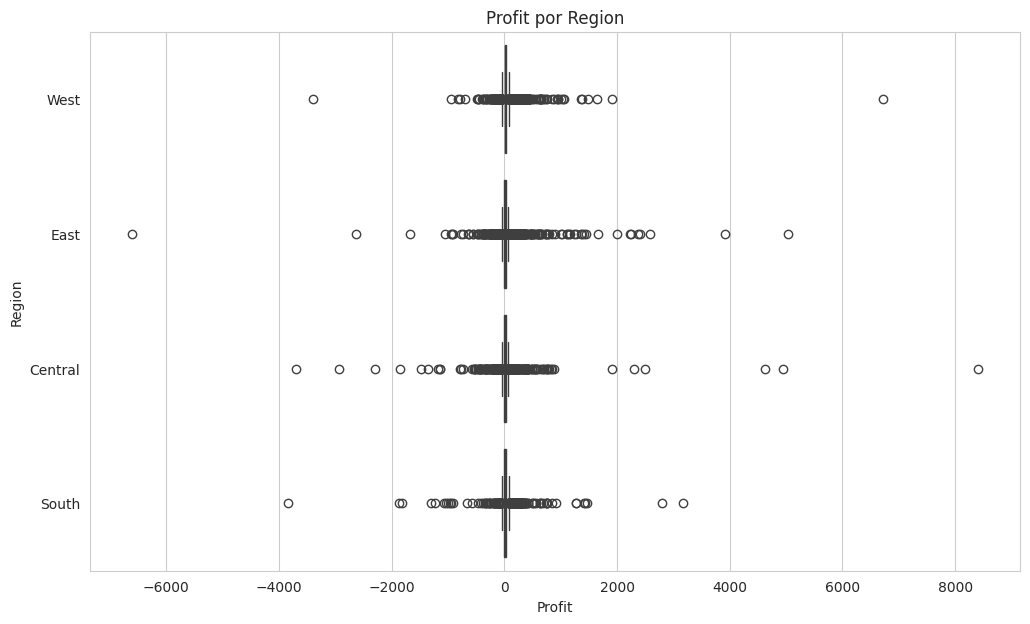

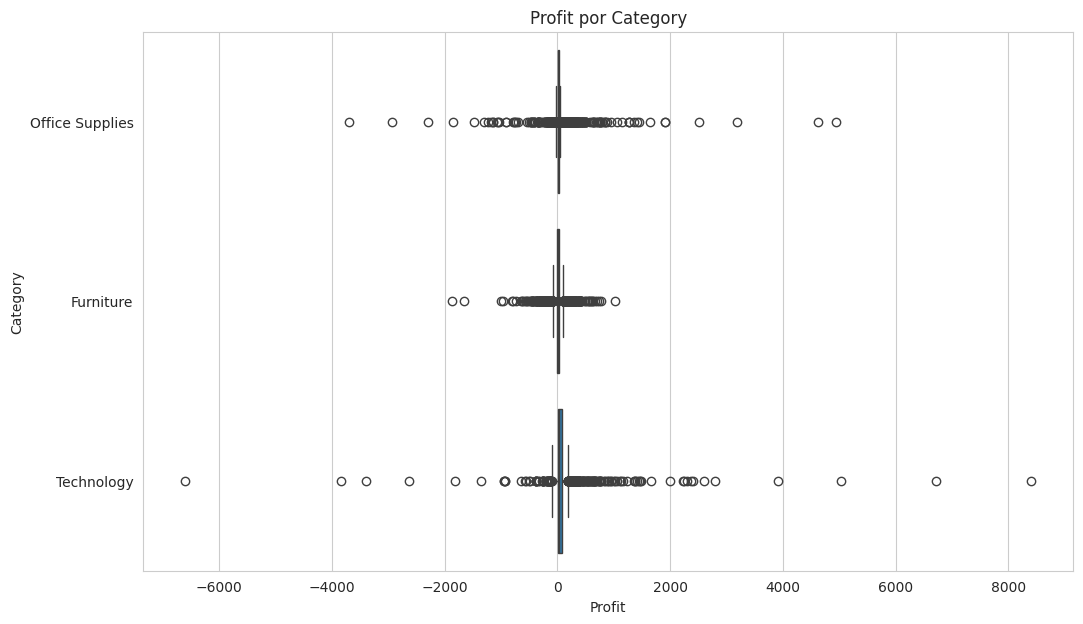

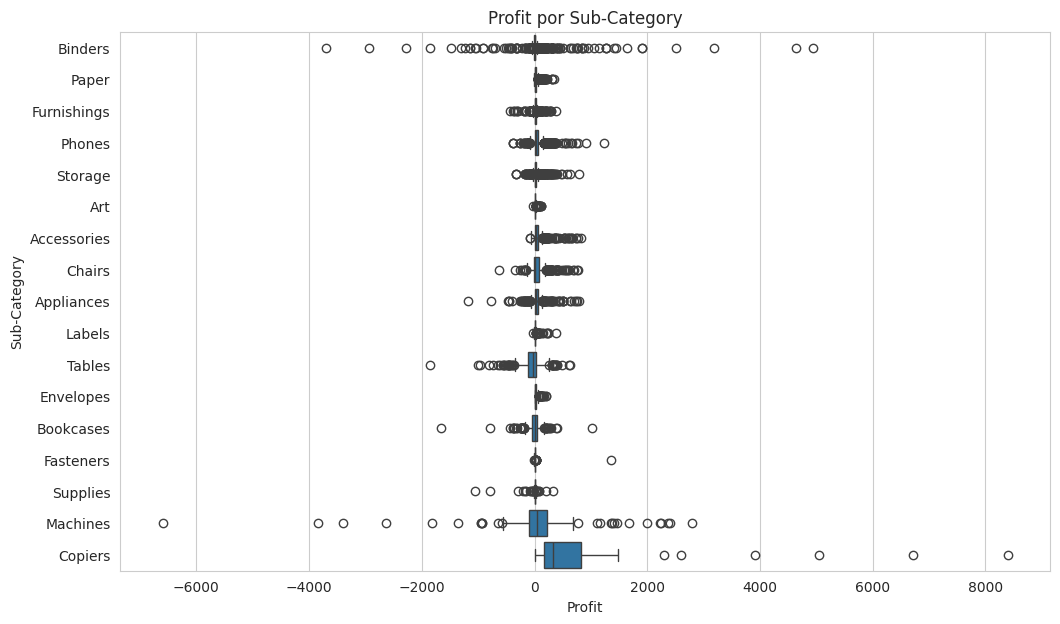

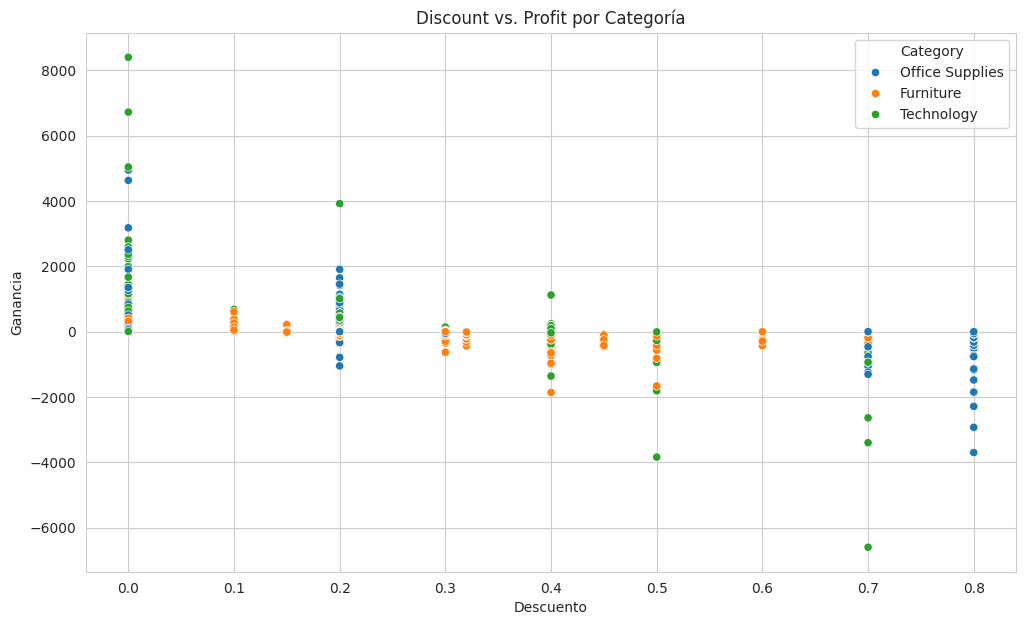

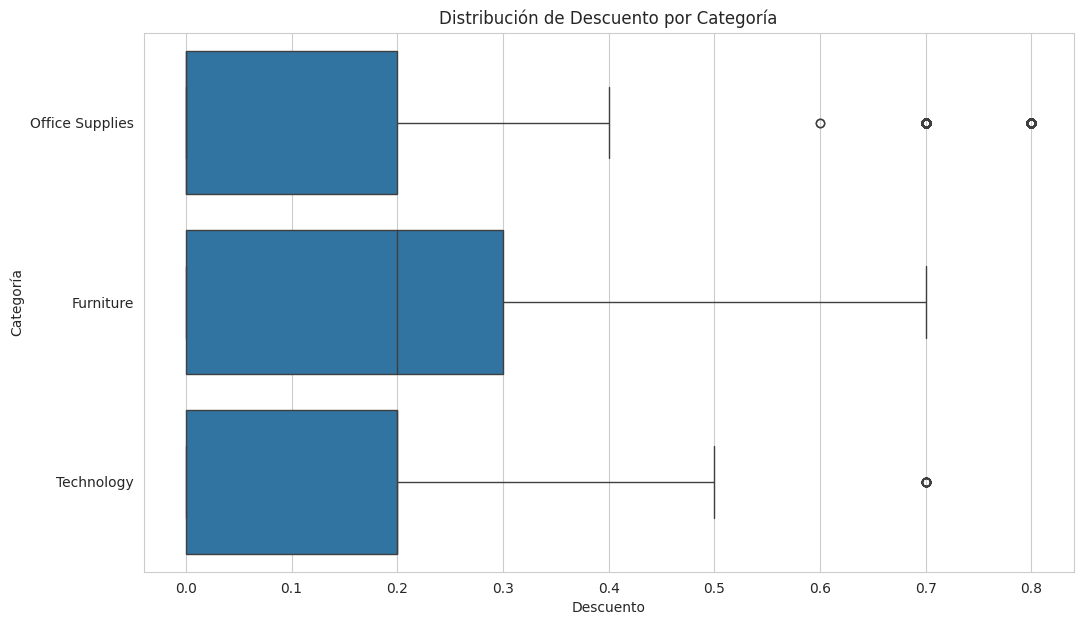

In [9]:
print("\n--- Correlación entre variables numéricas y 'Profit' ---")
correlation_matrix = df[numerical_cols + ['Profit']].corr()
display(correlation_matrix['Profit'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

print("\n--- Scatterplots de variables numéricas vs. 'Profit' ---")
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df[col], y=df['Profit'])
    plt.title(f'{col} vs. Profit')
    plt.xlabel(col)
    plt.ylabel('Profit')
    plt.show()

print("\n--- Boxplots de variables categóricas vs. 'Profit' ---")
for col in categorical_cols:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x=df['Profit'], y=df[col], order=df[col].value_counts().index)
    plt.title(f'Profit por {col}')
    plt.xlabel('Profit')
    plt.ylabel(col)
    plt.show()

# Análisis de la relación entre Discount y Profit
plt.figure(figsize=(12, 7))
sns.scatterplot(x=df['Discount'], y=df['Profit'], hue=df['Category'])
plt.title('Discount vs. Profit por Categoría')
plt.xlabel('Descuento')
plt.ylabel('Ganancia')
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(x=df['Discount'], y=df['Category'])
plt.title('Distribución de Descuento por Categoría')
plt.xlabel('Descuento')
plt.ylabel('Categoría')
plt.show()

## 7. Análisis Geográfico Interactivo (Folium)

Las gráficas anteriores (secciones 4–6) siguen siendo nuestra base descriptiva. En esta sección las **complementamos** con mapas interactivos construidos con `folium` para visualizar la dimensión geográfica de la rentabilidad:

- **Choropleth por estado:** colorea cada estado de EE. UU. según el `Profit` (y las `Sales`) totales.
- **Mapa de burbujas por ciudad:** ubica cada ciudad a partir de su código postal (vía `pgeocode`); el tamaño de la burbuja es proporcional a las ventas y el color indica si la ciudad es rentable (verde) o genera pérdidas (rojo).

> **Nota:** el GeoJSON utilizado contiene únicamente los estados de EE. UU., por lo que las provincias de Canadá y el Distrito de Columbia aparecen en gris en el choropleth. El mapa de ciudades sí cubre ambos países a partir del código postal.

In [10]:
# --- Librerías para mapas interactivos ---
import os
import json
import urllib.request
import folium
import pgeocode

# GeoJSON con los polígonos de los estados de EE. UU.
# Se descarga una sola vez y se cachea localmente para que el notebook sea reproducible.
GEOJSON_URL = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/us-states.json"
GEOJSON_PATH = "us-states.json"
if not os.path.exists(GEOJSON_PATH):
    urllib.request.urlretrieve(GEOJSON_URL, GEOJSON_PATH)
with open(GEOJSON_PATH, "r") as f:
    us_states_geojson = json.load(f)

# Centro aproximado de los mapas (EE. UU. continental)
MAP_CENTER = [39.5, -98.35]
print(f"GeoJSON cargado: {len(us_states_geojson['features'])} estados de EE. UU.")

GeoJSON cargado: 50 estados de EE. UU.


### 7.1 Choropleth: rentabilidad y ventas por estado

Agregamos el `Profit` y las `Sales` totales por estado y los proyectamos sobre el mapa. En el choropleth de `Profit`, el rojo señala estados con pérdidas netas y el verde estados rentables.

In [11]:
# Profit total agregado por estado/provincia
state_profit = df.groupby('State/Province', as_index=False)['Profit'].sum()

mapa_profit = folium.Map(location=MAP_CENTER, zoom_start=4, tiles='cartodbpositron')
folium.Choropleth(
    geo_data=us_states_geojson,
    data=state_profit,
    columns=['State/Province', 'Profit'],
    key_on='feature.properties.name',
    fill_color='RdYlGn',           # rojo = pérdidas, verde = ganancias
    nan_fill_color='lightgray',    # estados fuera del GeoJSON (provincias de Canadá, DC)
    fill_opacity=0.85,
    line_opacity=0.3,
    legend_name='Profit total (USD) por estado',
).add_to(mapa_profit)
mapa_profit

In [12]:
# Sales totales agregadas por estado/provincia
state_sales = df.groupby('State/Province', as_index=False)['Sales'].sum()

mapa_sales = folium.Map(location=MAP_CENTER, zoom_start=4, tiles='cartodbpositron')
folium.Choropleth(
    geo_data=us_states_geojson,
    data=state_sales,
    columns=['State/Province', 'Sales'],
    key_on='feature.properties.name',
    fill_color='YlGnBu',
    nan_fill_color='lightgray',
    fill_opacity=0.85,
    line_opacity=0.3,
    legend_name='Ventas totales (USD) por estado',
).add_to(mapa_sales)
mapa_sales

### 7.2 Mapa de burbujas: ventas y rentabilidad por ciudad

Geocodificamos cada registro por su **código postal** (`pgeocode`, distinguiendo EE. UU. de Canadá) y agregamos las métricas por ciudad. Cada burbuja representa una ciudad: su **tamaño** es proporcional a las ventas totales y su **color** indica si la ciudad es rentable (verde) o genera pérdidas (rojo). Haz clic en una burbuja para ver el detalle.

In [13]:
# Geocodificación por código postal según el país.
# pgeocode descarga y cachea los datos de cada país la primera vez que se usa.
def coords_por_codigo_postal(country_code, postal_series):
    nomi = pgeocode.Nominatim(country_code)
    codigos = postal_series.dropna().astype(str).unique().tolist()
    res = nomi.query_postal_code(codigos)[['postal_code', 'latitude', 'longitude']]
    res['postal_code'] = res['postal_code'].astype(str)
    return dict(zip(res['postal_code'], zip(res['latitude'], res['longitude'])))

df['_pc'] = df['Postal Code'].astype(str)
lut = {}
lut.update(coords_por_codigo_postal('us', df.loc[df['Country/Region'] == 'United States', '_pc']))
lut.update(coords_por_codigo_postal('ca', df.loc[df['Country/Region'] == 'Canada', '_pc']))
df['lat'] = df['_pc'].map(lambda p: lut.get(p, (np.nan, np.nan))[0])
df['lon'] = df['_pc'].map(lambda p: lut.get(p, (np.nan, np.nan))[1])

sin_coords = df[['lat', 'lon']].isna().any(axis=1).sum()
print(f"Filas sin coordenada (código postal no resuelto): {sin_coords} de {len(df)} ({sin_coords/len(df):.1%})")

# Agregación de métricas por ciudad
ciudades = (df.dropna(subset=['lat', 'lon'])
              .groupby(['City', 'State/Province'], as_index=False)
              .agg(Sales=('Sales', 'sum'),
                   Profit=('Profit', 'sum'),
                   Pedidos=('Profit', 'size'),
                   lat=('lat', 'mean'),
                   lon=('lon', 'mean')))
print(f"Ciudades geolocalizadas: {len(ciudades)}")

mapa_ciudades = folium.Map(location=MAP_CENTER, zoom_start=4, tiles='cartodbpositron')
sales_max = ciudades['Sales'].max()
for _, r in ciudades.iterrows():
    folium.CircleMarker(
        location=[r['lat'], r['lon']],
        radius=3 + 17 * np.sqrt(r['Sales'] / sales_max),    # tamaño proporcional a las ventas
        color='#2c7a2c' if r['Profit'] >= 0 else '#b22222',  # verde = rentable, rojo = pérdida
        fill=True,
        fill_opacity=0.6,
        weight=1,
        popup=folium.Popup(
            f"<b>{r['City']}, {r['State/Province']}</b><br>"
            f"Ventas: ${r['Sales']:,.0f}<br>"
            f"Profit: ${r['Profit']:,.0f}<br>"
            f"Pedidos: {int(r['Pedidos'])}",
            max_width=260),
    ).add_to(mapa_ciudades)
mapa_ciudades

Filas sin coordenada (código postal no resuelto): 438 de 10194 (4.3%)
Ciudades geolocalizadas: 565


## 8. Hallazgos y Conclusiones

Aquí se resumen los principales descubrimientos del EDA y se responden las preguntas clave para el equipo.

### Variables con Mayor Relación con el Target (`Profit`):

- **`Sales` (Ventas):** Existe una correlación positiva moderada con `Profit`. Generalmente, mayores ventas tienden a generar mayores ganancias, aunque la dispersión en el scatterplot sugiere que no siempre es lineal y otros factores influyen.
- **`Discount` (Descuento):** Muestra una fuerte correlación negativa con `Profit`. A medida que el descuento aumenta, la ganancia tiende a disminuir drásticamente, incluso llevando a pérdidas significativas. Esta es una variable crítica a considerar.
- **`Quantity` (Cantidad):** Tiene una correlación positiva débil con `Profit`. Vender más unidades no siempre se traduce directamente en más ganancias, especialmente si los descuentos son altos.
- **`Category` y `Sub-Category`:** Estas variables categóricas tienen un impacto significativo en la distribución de `Profit`. Por ejemplo, algunas categorías como 'Technology' y 'Office Supplies' pueden ser más rentables que 'Furniture', que a menudo muestra pérdidas debido a altos descuentos o costos.
- **`Region`, `State/Province`, `City`:** La ubicación geográfica también influye en la rentabilidad, con algunas regiones o estados mostrando consistentemente mayores ganancias o pérdidas promedio. Esto podría estar relacionado con la competencia, la demanda o las políticas de precios/descuentos locales.

### Desbalance de Clases (en relación a `Profit`):

- La variable `Profit` en sí misma no es una variable de clase, sino una variable numérica continua. Sin embargo, si consideramos la clasificación de transacciones como 'Rentables' (Profit > 0) vs. 'No Rentables/Pérdida' (Profit <= 0), hemos observado que una parte significativa de las transacciones (aproximadamente el 20-25%) resultan en pérdidas o ganancias nulas. Esto indica un desbalance en la rentabilidad que debe ser abordado, quizás enfocándose en reducir las pérdidas.

### Variables que Requieren Transformación:

- **`Profit`, `Sales`, `Quantity`, `Discount`:** Todas estas variables numéricas muestran una alta asimetría (skewness) y la presencia de numerosos outliers, como se observa en los histogramas y boxplots. Esto sugiere que podrían beneficiarse de transformaciones (ej. logarítmica, raíz cuadrada) para normalizar sus distribuciones antes de ser utilizadas en modelos predictivos que asumen normalidad o para reducir la influencia de los outliers.
- Las variables de fecha (`Order Date`, `Ship Date`) ya fueron transformadas a tipo datetime, lo que permitirá extraer características temporales (año, mes, día de la semana, duración del envío) que podrían ser útiles.

### Variables Redundantes:

- **`Row ID`, `Order ID`, `Customer ID`, `Product ID`:** Estas son variables identificadoras únicas que no aportan valor predictivo directo y pueden ser eliminadas o ignoradas para el modelado, aunque `Product ID` y `Customer ID` podrían ser útiles para agrupar datos y crear nuevas características (ej. número de pedidos por cliente, ventas promedio por producto).
- **`Customer Name`, `Product Name`:** Son descripciones textuales que, si bien son informativas, no son directamente utilizables en la mayoría de los modelos sin un procesamiento de lenguaje natural (NLP) complejo. Para un modelado inicial, pueden considerarse redundantes o de baja prioridad.
- **`Country/Region`:** Dado que todos los registros son de 'United States' (según la inspección inicial), esta columna es redundante si el análisis se limita a este país. Si hubiera múltiples países, sería una variable importante.

### Variables Seleccionadas para el Modelado (Propuesta Inicial):

Basado en el EDA, las siguientes variables son candidatas fuertes para el modelado de `Profit`:

- **Variables Numéricas (después de posibles transformaciones y tratamiento de outliers):**
    - `Sales`
    - `Quantity`
    - `Discount`
- **Variables Categóricas (después de codificación one-hot o similar):**
    - `Ship Mode`
    - `Segment`
    - `City` (considerando la alta cardinalidad, podría requerir agrupamiento o técnicas de codificación avanzadas)
    - `State/Province`
    - `Region`
    - `Category`
    - `Sub-Category`
- **Variables Temporales (derivadas de `Order Date` y `Ship Date`):**
    - Duración del envío (`Ship Date` - `Order Date`)
    - Año, mes, día de la semana del pedido (para identificar tendencias estacionales).

El `Postal Code` podría ser útil para análisis geográficos más detallados o para agrupar ciudades/estados, pero su alta cardinalidad y la presencia de nulos (si no se tratan adecuadamente) lo hacen menos prioritario para un modelo inicial.